# 01 — Baseline evaluation
Train YOLOv8n with default settings on COCO 2017 and evaluate.  
Once you're happy with the results, the training and eval calls get extracted into `scripts/train_baseline.py` and `scripts/evaluate.py`.

## 0. Setup

In [1]:
# Install dependencies if needed
# !pip install ultralytics pycocotools matplotlib

In [2]:
import json
import random
import shutil
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from ultralytics import YOLO
from ultralytics.data.converter import convert_coco
%matplotlib inline


print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.11.0+cu130
CUDA     : True
GPU      : NVIDIA GeForce RTX 2080 SUPER


In [3]:
# Paths
PROJECT_ROOT = Path("..").resolve()        # object-detection-hw/
COCO_ROOT    = PROJECT_ROOT / "data"
DATA_YAML    = PROJECT_ROOT / "data" / "coco.yaml"

SUBSET_DIR = PROJECT_ROOT / "data" / "coco_subset"
DATA_SUBSET_YAML = PROJECT_ROOT / "data" / "coco_subset.yaml"

CONFIG_YAML  = PROJECT_ROOT / "configs" / "baseline.yaml"
RESULTS_DIR  = PROJECT_ROOT / "results" / "baseline"
RESULTS_DIR.mkdir(exist_ok=True)

TRAIN_IMAGES = SUBSET_DIR / "images" / "train"
VAL_IMAGES = SUBSET_DIR / "images" / "val"

print("Train images exist:", TRAIN_IMAGES.exists())
print("Val images exist:", VAL_IMAGES.exists())

Train images exist: True
Val images exist: True


In [4]:
N_IMAGES   = 3000          # adjust to taste — 1000 is fast, 3000 is more meaningful
TRAIN_SPLIT = 0.8

random.seed(42)

with open(COCO_ROOT / "annotations" / "instances_val2017.json") as f:
    data = json.load(f)

# Shuffle and split images
imgs = data["images"].copy()
random.shuffle(imgs)
train_imgs = imgs[:int(N_IMAGES * TRAIN_SPLIT)]
val_imgs   = imgs[int(N_IMAGES * TRAIN_SPLIT):N_IMAGES]

train_ids = {img["id"] for img in train_imgs}
val_ids   = {img["id"] for img in val_imgs}

def write_subset(subset_imgs, img_ids, split_name):
    img_out = SUBSET_DIR / "images" / split_name
    ann_out = SUBSET_DIR / "annotations"
    img_out.mkdir(parents=True, exist_ok=True)
    ann_out.mkdir(parents=True, exist_ok=True)

    # Copy images
    for img in subset_imgs:
        src = COCO_ROOT / "images" / "val2017" / img["file_name"]
        shutil.copy(src, img_out / img["file_name"])

    # Filter annotations
    anns = [a for a in data["annotations"] if a["image_id"] in img_ids]

    subset_json = {
        "images":      subset_imgs,
        "annotations": anns,
        "categories":  data["categories"],
    }
    with open(ann_out / f"instances_{split_name}.json", "w") as f:
        json.dump(subset_json, f)

    print(f"{split_name}: {len(subset_imgs)} images, {len(anns)} annotations")

write_subset(train_imgs, train_ids, "train")
write_subset(val_imgs,   val_ids,   "val")

train: 2400 images, 17636 annotations
val: 600 images, 4169 annotations


In [5]:
def convert_coco_subset_to_yolo(split):
    ann_file = SUBSET_DIR / "annotations" / f"instances_{split}.json"
    out_dir  = SUBSET_DIR / "labels" / split
    out_dir.mkdir(parents=True, exist_ok=True)

    with open(ann_file) as f:
        data = json.load(f)

    # Build image id → (filename, w, h) lookup
    images = {
        img["id"]: (img["file_name"], img["width"], img["height"])
        for img in data["images"]
    }

    # Build category id → contiguous 0-based index
    cat_ids = sorted(c["id"] for c in data["categories"])
    cat_map  = {cid: i for i, cid in enumerate(cat_ids)}

    # Group annotations by image
    from collections import defaultdict
    ann_by_image = defaultdict(list)
    for ann in data["annotations"]:
        # Skip crowd annotations and anything missing bbox
        if ann.get("iscrowd", 0) == 1:
            continue
        if "bbox" not in ann:
            continue
        if len(ann["bbox"]) != 4:
            continue
        ann_by_image[ann["image_id"]].append(ann)

    # Write one .txt per image
    for img_id, (fname, w, h) in images.items():
        anns = ann_by_image[img_id]
        label_path = out_dir / (Path(fname).stem + ".txt")

        if not anns:
            label_path.touch()   # empty file — image exists but has no objects
            continue

        lines = []
        for ann in anns:
            x, y, bw, bh = ann["bbox"]          # COCO: top-left x, y, width, height
            cx = (x + bw / 2) / w               # YOLO: center x normalized
            cy = (y + bh / 2) / h
            nw = bw / w
            nh = bh / h

            # Skip degenerate boxes
            if bw <= 0 or bh <= 0:
                continue

            cls = cat_map[ann["category_id"]]
            lines.append(f"{cls} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

        label_path.write_text("\n".join(lines))

    print(f"{split}: {len(images)} images, {sum(len(v) for v in ann_by_image.values())} annotations written to {out_dir}")

convert_coco_subset_to_yolo("train")
convert_coco_subset_to_yolo("val")

train: 2400 images, 17636 annotations written to /home/paul/Desktop/projects/deep-learning/homework2/data/coco_subset/labels/train
val: 600 images, 4169 annotations written to /home/paul/Desktop/projects/deep-learning/homework2/data/coco_subset/labels/val


## 1. Train baseline
This cell trains YOLOv8n using `configs/baseline.yaml`.  
Skip and load an existing checkpoint if you've already trained.

In [6]:
model = YOLO("yolov8n.pt")  # downloads pretrained weights on first run

print("DATA_YAML :", DATA_SUBSET_YAML)   # sanity check before training
print("Exists    :", Path(DATA_SUBSET_YAML).exists())

results = model.train(cfg=CONFIG_YAML, data=DATA_SUBSET_YAML, project=PROJECT_ROOT / "runs") 


# Ultralytics saves the best checkpoint automatically
BEST_PT = Path(results.save_dir) / "weights" / "best.pt"
print("Best checkpoint:", BEST_PT)

DATA_YAML : /home/paul/Desktop/projects/deep-learning/homework2/data/coco_subset.yaml
Exists    : True
New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.35 🚀 Python-3.13.12 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080 SUPER, 7782MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=/home/paul/Desktop/projects/deep-learning/homework2/configs/baseline.yaml, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/paul/Desktop/projects/deep-learning/homework2/data/coco_subset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, h

In [7]:
# --- OR: load an existing checkpoint instead of retraining ---
# BEST_PT = Path("../runs/baseline/weights/best.pt")
# model   = YOLO(str(BEST_PT))

## 2. COCO-style evaluation

In [8]:
model = YOLO(str(BEST_PT))

metrics = model.val(
    data=str(DATA_SUBSET_YAML),
    imgsz=640,
    save_json=True,   # writes predictions_coco_format.json inside run dir
    verbose=True,
)

baseline_metrics = {
    "mAP50":     round(float(metrics.box.map50), 4),
    "mAP50_95":  round(float(metrics.box.map),   4),
    "precision": round(float(metrics.box.mp),    4),
    "recall":    round(float(metrics.box.mr),    4),
}

print(json.dumps(baseline_metrics, indent=2))

# Save for the comparison notebook
out = RESULTS_DIR / "baseline_coco_eval.json"
with open(out, "w") as f:
    json.dump(baseline_metrics, f, indent=2)
print(f"Saved → {out}")

Ultralytics 8.4.35 🚀 Python-3.13.12 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080 SUPER, 7782MiB)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2228.2±989.6 MB/s, size: 177.0 KB)
val: Scanning /home/paul/Desktop/projects/deep-learning/homework2/data/coco_subset/labels/val.cache... 600 images, 1005 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1600/1600 419.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 100/100 8.7it/s 11.5s0.1s
                   all       1600       4169       0.26      0.334      0.196      0.135
                person        318       1227      0.302      0.589      0.262      0.163
               bicycle         16         41      0.119     0.0976     0.0946     0.0407
                   car         57        209      0.211      0.378      0.138      0.078
            motorcycle         26         57      0.30

## 3. Training curves
Ultralytics writes a `results.csv` inside the run directory with per-epoch metrics.

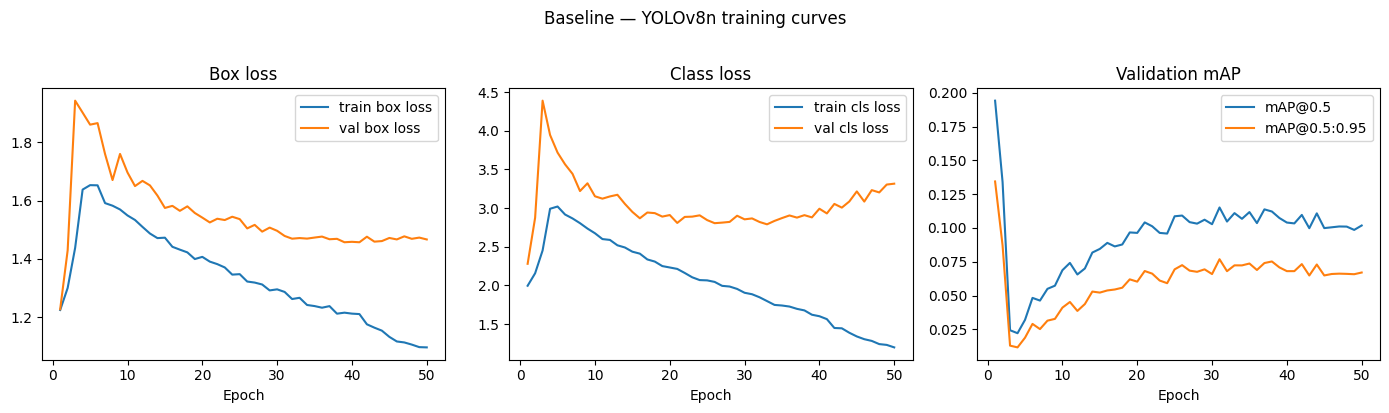

In [15]:
run_dir    = BEST_PT.parent.parent          # e.g. runs/baseline/
csv_path   = run_dir / "results.csv"

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()         # Ultralytics adds whitespace

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(df["epoch"], df["train/box_loss"], label="train box loss")
axes[0].plot(df["epoch"], df["val/box_loss"],   label="val box loss")
axes[0].set_title("Box loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(df["epoch"], df["train/cls_loss"], label="train cls loss")
axes[1].plot(df["epoch"], df["val/cls_loss"],   label="val cls loss")
axes[1].set_title("Class loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(df["epoch"], df["metrics/mAP50(B)"],    label="mAP@0.5")
axes[2].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
axes[2].set_title("Validation mAP")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.suptitle("Baseline — YOLOv8n training curves", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Per-class mAP
Which classes does the baseline struggle with most?

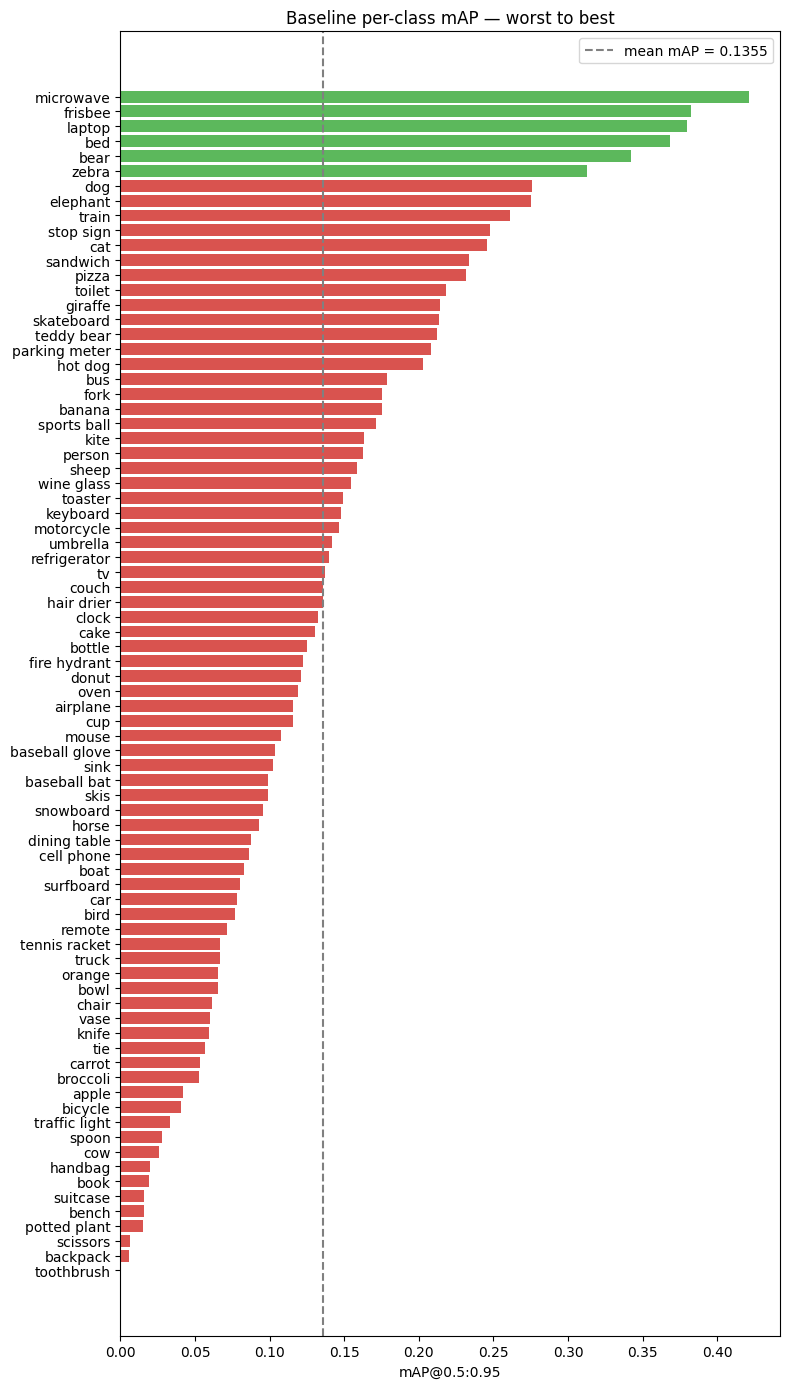


5 worst classes:
  toothbrush           0.0000
  backpack             0.0059
  scissors             0.0064
  potted plant         0.0151
  bench                0.0156


In [10]:
# metrics.box.maps is a numpy array of per-class mAP50-95
class_names = model.names   # dict {int: str}
per_class   = {class_names[i]: round(float(v), 4) for i, v in enumerate(metrics.box.maps)}

# Sort by mAP ascending so worst classes appear at top of the chart
sorted_classes = sorted(per_class.items(), key=lambda x: x[1])
names, scores  = zip(*sorted_classes)

fig, ax = plt.subplots(figsize=(8, 14))
bars = ax.barh(names, scores, color=["#d9534f" if s < 0.3 else "#5cb85c" for s in scores])
ax.axvline(baseline_metrics["mAP50_95"], linestyle="--", color="grey", label=f'mean mAP = {baseline_metrics["mAP50_95"]}')
ax.set_xlabel("mAP@0.5:0.95")
ax.set_title("Baseline per-class mAP — worst to best")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_per_class_map.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n5 worst classes:")
for name, score in sorted_classes[:5]:
    print(f"  {name:<20} {score:.4f}")

## 5. Visualize predictions on val images
Spot-check what the baseline model actually sees.

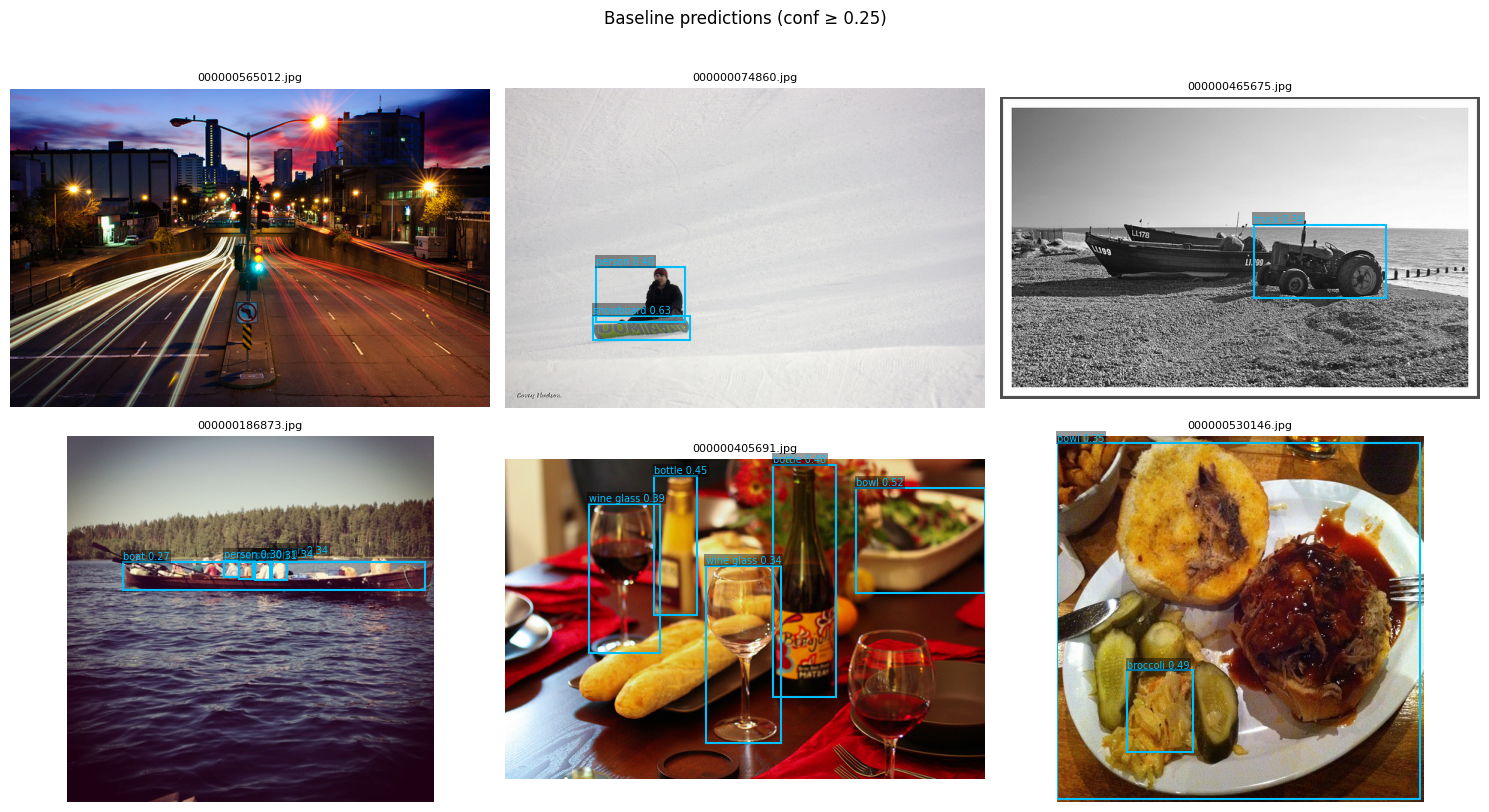

In [11]:
CONF_THRESH = 0.25
N_IMAGES    = 6

val_imgs = sorted(VAL_IMAGES.glob("*.jpg"))
sample   = random.sample(val_imgs, N_IMAGES)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, img_path in zip(axes, sample):
    result = model.predict(str(img_path), conf=CONF_THRESH, verbose=False)[0]
    img    = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.axis("off")

    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf  = float(box.conf[0])
        cls   = int(box.cls[0])
        label = f"{model.names[cls]} {conf:.2f}"
        rect  = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=1.5, edgecolor="#00bfff", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, label, fontsize=7, color="#00bfff",
                bbox=dict(facecolor="black", alpha=0.4, pad=1, edgecolor="none"))

    ax.set_title(img_path.name, fontsize=8)

plt.suptitle(f"Baseline predictions (conf ≥ {CONF_THRESH})", y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Confidence score distribution
Useful for checking whether the model is over- or under-confident — informs whether you need label smoothing or confidence calibration.

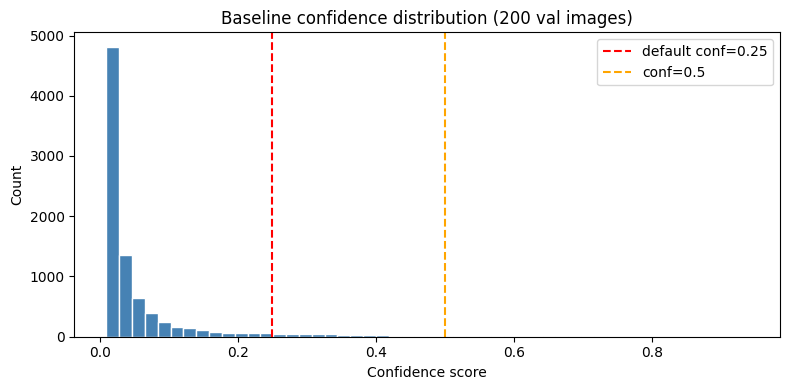

Total boxes sampled : 8643
Median confidence   : 0.025
Boxes above 0.5     : 75 (0.9%)


In [12]:
N_SAMPLE  = 200   # number of val images to run inference on
all_confs = []

sample_paths = random.sample(val_imgs, N_SAMPLE)
preds = model.predict(sample_paths, conf=0.01, verbose=False)  # low threshold to capture all boxes

for r in preds:
    all_confs.extend(r.boxes.conf.tolist())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(all_confs, bins=50, color="steelblue", edgecolor="white")
ax.axvline(0.25, color="red",    linestyle="--", label="default conf=0.25")
ax.axvline(0.5,  color="orange", linestyle="--", label="conf=0.5")
ax.set_xlabel("Confidence score")
ax.set_ylabel("Count")
ax.set_title(f"Baseline confidence distribution ({N_SAMPLE} val images)")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_conf_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total boxes sampled : {len(all_confs)}")
print(f"Median confidence   : {np.median(all_confs):.3f}")
print(f"Boxes above 0.5     : {sum(c > 0.5 for c in all_confs)} ({100*sum(c>0.5 for c in all_confs)/len(all_confs):.1f}%)")

## 7. Summary
Print all numbers in one place — copy these into your README as the baseline row.

In [14]:
print("=" * 40)
print("BASELINE — YOLOv8n on COCO val2017")
print("=" * 40)
for k, v in baseline_metrics.items():
    print(f"  {k:<15} {v:.4f}")
# print()
# print("Checkpoint :", BEST_PT)
# print("Results dir:", RESULTS_DIR)
# print()

BASELINE — YOLOv8n on COCO val2017
  mAP50           0.1964
  mAP50_95        0.1355
  precision       0.2599
  recall          0.3336
